<a href="https://colab.research.google.com/github/tegga8/GEN_AI_Fundamentals/blob/main/VAE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from keras import layers, Model
import matplotlib.pyplot as plt

Loading the data


In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
# normalisation
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# 2D-->1D
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


Sampling layer

In [3]:
latent_dim = 64

class Sampling(layers.Layer):
  def call(self, inputs):
    z_mean, z_log_var = inputs
    epsilon = tf.random.normal(
        shape = tf.shape(z_mean)
    )
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

Encoder Layer

In [4]:
encoder_inputs = tf.keras.Input(shape=(784,))
x = layers.Dense(256, activation='relu')(encoder_inputs)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = tf.keras.Model(encoder_inputs,[z_mean, z_log_var, z], name='Encoder')

Decoder Layer

In [5]:
latent_inputs = layers.Input(shape = (latent_dim,))
x = layers.Dense(256, activation='relu')(latent_inputs)
decoder_outputs = layers.Dense(784, activation='sigmoid')(x)
decoder = tf.keras.Model(latent_inputs, decoder_outputs, name='Decoder')

VAE Model

In [6]:
class VAE(tf.keras.Model):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def call(self, inputs):
    z_mean, z_log_var, z = self.encoder(inputs)
    reconstructed = self.decoder(z)
    return reconstructed

  def train_step(self, data):

    if isinstance(data, tuple):
        data = data[0]

    with tf.GradientTape() as tape:
        z_mean, z_log_var, z = self.encoder(data)
        reconstructed = self.decoder(z)

        # Reconstruction Loss
        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(data, reconstructed)
        )

        # KL Divergence Loss
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

    grads = tape.gradient(total_loss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

    return {
        'loss': total_loss,
        'reconstruction_loss': reconstruction_loss,
        'kl_loss': kl_loss
    }




Creating VAE

In [7]:
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

# Training

history = vae.fit(x_train, epochs=25, batch_size=128)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - kl_loss: 2.1959e-04 - loss: 0.2677 - reconstruction_loss: 0.2675
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: 1.4664e-05 - loss: 0.2676 - reconstruction_loss: 0.2675
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 5.9453e-06 - loss: 0.2499 - reconstruction_loss: 0.2499
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - kl_loss: -0.0000e+00 - loss: 0.2674 - reconstruction_loss: 0.2674
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 2.3491e-06 - loss: 0.2712 - reconstruction_loss: 0.2712
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: -0.0000e+00 - loss: 0.2678 - reconstruction_loss: 0.2678
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: -0.0000e+00 - loss: 0.2656 - reconstruction_loss: 0.2656
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - kl_loss: -0.0000e+00 - loss: 0.2650 - reconstruction_loss: 0.2650
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━

Reconstruction of Test Images

In [8]:
z_mean, z_log_var, z = encoder.predict(x_test[:10])
reconstructed = decoder.predict(z)
reconstructed.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


(10, 784)

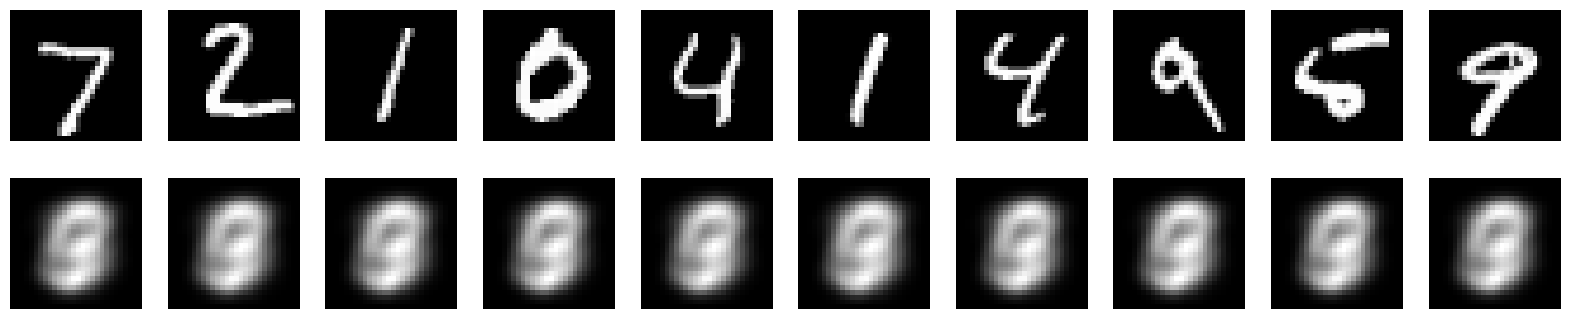

In [9]:
# Plotting the images
plt.figure(figsize = (20, 4))
for i in range(10):
  ax = plt.subplot(2, 10, i+1)
  plt.imshow(x_test[i].reshape(28, 28), cmap = "gray")
  plt.axis("off")

  # Reconstructed
  ax = plt.subplot(2, 10, i+11)
  plt.imshow(reconstructed[i].reshape(28, 28), cmap = "gray")
  plt.axis("off")

plt.show()

In [10]:
# The blurriness in VAEs often results from the model attempting
# to cover the uncertainty in the latent space. Since it maps to
# a distribution rather than a point, the decoder might output an average
# of multiple possible reconstructions, leading to a blurry result.
# Standard autoencoders, not being constrained to this probabilistic output,
# do not have this "averaging" pressure, making them sharper but less effective
# at interpolation or generating entirely new samples.